In [1]:
import pickle
from pprint import pprint

p = 'congress-stemmed-ws-2-ns-1-vocab-5000-train-gibbs-N-10000000-D-100--wfxu'
fname = "sample-0.pkl"
fname = p + '/' + fname

with open(fname, "rb") as f:
    obj = pickle.load(f)

print(type(obj))

if isinstance(obj, dict):
    print("\nDICT KEYS:")
    pprint(obj.keys())

elif hasattr(obj, "__dict__"):
    print("\nATTRIBUTES:")
    pprint(vars(obj).keys())

else:
    print(obj)

<class 'dict'>

DICT KEYS:
dict_keys(['theta', 'vocabulary', 'lambda0'])


In [6]:
import json

vocab = obj["vocabulary"]

# inspect type first
print(type(vocab))

# save readable version
with open("vocabulary.json", "w") as f:
    json.dump(vocab, f, indent=2)

<class 'dict'>


In [80]:
'men' in vocab

True

In [88]:
import numpy as np
import pickle
import glob

pos = [
    "freedom", "opportun", "prosper",
    "growth", "success", "legal", "famili"
]

neg = [
    "crime", "threat", "illeg",
    "terror", "violenc", "drug",
    "border", "deport"
]


pos = ["good", "great", "best", "success", "strong", "honor", "fair", "safe", "freedom", "respect", "hope"]
neg =  ["bad", "worst",  "violent", "violenc", "threat", "danger", "fail", "corrupt", "fraud", "terror", "war"] # removed ccrime



welfare =  ["welfar", "poverti", "poor", "lowincom", "afdc", "food", "benefit", "unemploy"] #medicaid
wealth = ["rich", "wealth", "wealthi", "profit", "bank", "investor", "corpor", "market"]

male = ["man", "men", "male", "he", "him", "his", "father", "son", "brother", "husband", "boy", "gentleman"]
female = ["woman", "women", "she", "her", "herself", "mother", "daughter", "sister", "wife", "girl", "gentlewoman"]
positive = welfare
negative = wealth

def normalize_rows(M):
    return M / np.linalg.norm(M, axis=1, keepdims=True)

scores = []

sample_files = sorted(glob.glob(p+ '/' + "sample-*.pkl"))

for path in sample_files:

    with open(path, "rb") as f:
        obj = pickle.load(f)

    theta = obj["theta"]
    vocab = {
        w: i for w, i in obj["vocabulary"].items()
        if not w.endswith("_c") and i < 5000
    }

    rho = normalize_rows(theta[:5000])

    target = "medicaid"

    if target not in vocab:
        continue

    target_vec = rho[vocab[target]]

    pos_idx = [vocab[w] for w in positive if w in vocab]
    neg_idx = [vocab[w] for w in negative if w in vocab]

    pos_score = np.mean(rho[pos_idx] @ target_vec)
    neg_score = np.mean(rho[neg_idx] @ target_vec)

    scores.append(pos_score - neg_score)

scores = np.array(scores)

scores

print("posterior mean:", scores.mean())
print("posterior sd:", scores.std(ddof=1))
print("95% CI:", np.quantile(scores, [0.025, 0.975]))
print("Pr(score > 0):", np.mean(scores > 0))

posterior mean: 0.07887607048434095
posterior sd: 0.04535120811445997
95% CI: [-0.01095285  0.16932909]
Pr(score > 0): 0.9585


In [89]:
np.savetxt('medicaid_welfare_wealth.txt', scores)

In [86]:
scores  = np.loadtxt('medicaid_welfare_wealth.txt', dtype=float)

In [31]:

print("posterior mean:", scores.mean())
print("posterior sd:", scores.std(ddof=1))
print("95% CI:", np.quantile(scores, [0.025, 0.975]))
print("Pr(score > 0):", np.mean(scores > 0))

posterior mean: 0.06408867641361797
posterior sd: 0.03552735182226305
95% CI: [-0.0019728   0.13561496]
Pr(score > 0): 0.9685


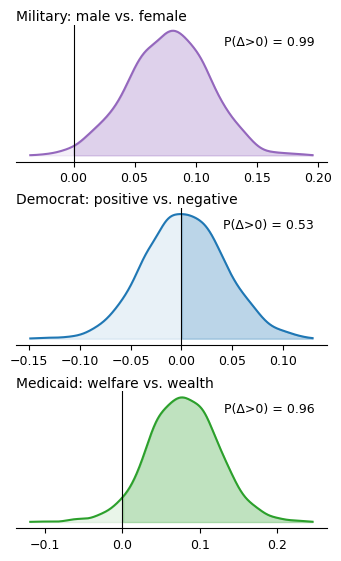

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

crime_man_woman      = np.loadtxt("militari_male_female.txt")
crime_neg_pos        = np.loadtxt("democrat_pos_neg.txt")
crime_wealth_welfare = np.loadtxt("medicaid_welfare_wealth.txt")

results = {
    "Military: male vs. female":       (crime_man_woman,      "tab:purple"),
    "Democrat: positive vs. negative": (crime_neg_pos,         "tab:blue"),
    "Medicaid: welfare vs. wealth":    (crime_wealth_welfare,  "tab:green"),
}

fig, axes = plt.subplots(3, 1, figsize=(3.3, 5.5), constrained_layout=True)

for ax, (label, (scores, color)) in zip(axes, results.items()):
    scores   = np.asarray(scores)
    mean     = scores.mean()
    prob_pos = np.mean(scores > 0)

    kde = gaussian_kde(scores, bw_method="scott")
    xs  = np.linspace(scores.min() - 0.01, scores.max() + 0.01, 500)
    ys  = kde(xs)

    ax.fill_between(xs, ys, where=(xs < 0),  color=color, alpha=0.10)
    ax.fill_between(xs, ys, where=(xs >= 0), color=color, alpha=0.30)
    ax.plot(xs, ys, color=color, lw=1.5)
    ax.axvline(0, color="black", lw=0.8, ls="-")

    side   = 0.96 if mean > 0 else 0.04
    anchor = "right" if mean > 0 else "left"
    ax.text(
        side, 0.92,
        f"P(Δ>0) = {prob_pos:.2f}",
        transform=ax.transAxes,
        ha=anchor, va="top",
        fontsize=9,
    )

    ax.set_title(label, loc="left", fontsize=10, pad=3)
    ax.set_yticks([])
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.tick_params(axis="x", labelsize=9)   # black by default, no color override

#axes[-1].set_xlabel("Cosine association score (Δ)", fontsize=10)

fig.savefig("posterior_association.pdf", bbox_inches="tight")
plt.show()

In [7]:
'son' in obj['vocabulary']

True

In [24]:
import numpy as np
import pickle
import glob

positive = [
    "good" , "freedom", "opportun", "prosper",
    "growth", "success", "legal", "famili"
]

negative = [
    "crime", "threat", "illeg",
    "terror", "violenc", "drug",
    "border", "deport"
]

positive= ["good", "great", "best", "success", "strong", "honor", "fair", "safe", "freedom", "respect", "hope"]
negative = ["bad", "worst", "crime", "violent", "violenc", "threat", "danger", "fail", "corrupt", "fraud", "terror", "war"]

male =  ["man", "men", "male", "he", "him", "his", "father", "son", "brother", "husband", "boy", "gentleman"]
female = ["woman", "women", "she", "her", "herself", "mother", "daughter", "sister", "wife", "girl", "gentlewoman"]
positive = male
negative = female

def normalize_rows(M):
    return M / np.linalg.norm(M, axis=1, keepdims=True)

scores = []

sample_files = sorted(glob.glob(p + '/' + "sample-*.pkl"))

for path in sample_files:

    with open(path, "rb") as f:
        obj = pickle.load(f)

    theta = obj["theta"]
    vocab = {
        w: i for w, i in obj["vocabulary"].items()
        if not w.endswith("_c") and i < 5000
    }

    rho = normalize_rows(theta[:5000])

    target = "crime"

    if target not in vocab:
        continue

    target_vec = rho[vocab[target]]

    pos_idx = [vocab[w] for w in positive if w in vocab]
    neg_idx = [vocab[w] for w in negative if w in vocab]

    pos_score = np.mean(rho[pos_idx] @ target_vec)
    neg_score = np.mean(rho[neg_idx] @ target_vec)

    scores.append(pos_score - neg_score)

scores = np.array(scores)

print("posterior mean:", scores.mean())
print("posterior sd:", scores.std(ddof=1))
print("95% CI:", np.quantile(scores, [0.025, 0.975]))
print("Pr(score > 0):", np.mean(scores > 0))

posterior mean: 0.06408867641361797
posterior sd: 0.03552735182226305
95% CI: [-0.0019728   0.13561496]
Pr(score > 0): 0.9685


In [ ]:
weat_groups = {
    "male": ["man", "men", "male", "he", "him", "his", "father", "son", "brother", "husband", "boy", "gentleman"],
    "female": ["woman", "women", "she", "her", "herself", "mother", "daughter", "sister", "wife", "girl", "gentlewoman"],

    "career": ["career", "profession", "execut", "corpor", "wage", "worker", "labor", "job", "employe", "work"],
    "family": ["home", "children", "child", "mother", "father", "parent", "wife", "husband", "marriag", "household"],

    "science": ["scientist", "scientif", "research", "laboratori", "technolog", "physic", "mathemat", "comput", "engin"],
    "arts": ["art", "artist", "music", "poet", "literatur", "novel", "book", "film", "theater"],

    "positive": ["good", "great", "best", "success", "strong", "honor", "fair", "safe", "freedom", "respect", "hope"],
    "negative": ["bad", "worst", "crime", "violent", "violenc", "threat", "danger", "fail", "corrupt", "fraud", "terror", "war"],

    "welfare": ["welfar", "poverti", "poor", "lowincom", "afdc", "medicaid", "food", "benefit", "unemploy"],
    "wealth": ["rich", "wealth", "wealthi", "profit", "bank", "investor", "corpor", "market"],

    "immigration": ["immigr", "migrant", "refuge", "alien", "deport", "border", "citizenship"],
    "crime": ["crime", "prison", "jail", "convict", "feloni", "arrest", "drug", "violenc", "weapon"],
}